# Nocca Nocca

## El juego

Nocca Nocca es un juego de tablero abstracto de **suma cero**, **información perfecta** y **dos jugadores** (Black y White) que se alternan turnos.

### Tablero y posición inicial

El tablero tiene **8 filas × 5 columnas** (filas 0–7, columnas 0–4). Cada celda puede contener una **torre** de hasta 3 fichas apiladas (niveles 0, 1, 2 de abajo hacia arriba).

Al inicio, **Black** tiene una ficha en cada columna de la fila 1 (`BLACK_START = 1`) y **White** una ficha en cada columna de la fila 6 (`WHITE_START = 6`). Ambos jugadores parten con **5 fichas**, una por columna.

```
fila 0:  . . . . .   ← meta de White (WHITE_GOAL)
fila 1:  B B B B B   ← inicio de Black
fila 2:  . . . . .
fila 3:  . . . . .
fila 4:  . . . . .
fila 5:  . . . . .
fila 6:  W W W W W   ← inicio de White
fila 7:  . . . . .   ← meta de Black (BLACK_GOAL)
```

### Movimiento

En cada turno el jugador activo mueve **exactamente una de sus fichas** en una de las 8 direcciones cardinales e intercardinales: N, S, E, W, NE, NW, SE, SW. Una ficha sólo puede moverse si **no está tapada** por una ficha rival en la misma torre (sólo se puede mover la ficha más alta del jugador en esa celda). La ficha se deposita en el nivel más bajo disponible de la celda destino.

Restricciones adicionales:
- **No salir del tablero** por los costados (columnas 0 y 4).
- **No moverse hacia la propia fila de salida**: Black no puede ir en dirección N/NW/NE desde la fila 1 (su fila de partida), evitando así entrar a la fila 0, que es la meta de White.  Simétricamente, White no puede ir en dirección S/SW/SE desde la fila 6.
- **No apilar en una torre llena** (las tres posiciones ocupadas).

### Condiciones de victoria

Un jugador **gana** si ocurre alguna de las dos situaciones siguientes:

1. **Llegada a la meta:** una de sus fichas ocupa el **nivel base (posición 0)** de cualquier celda en la fila contraria (fila 7 para Black, fila 0 para White).
2. **Bloqueo total del rival:** *todas* las fichas del rival están cubiertas por fichas propias en sus respectivas torres, de modo que el rival no tiene ningún movimiento legal.

Si se alcanza el límite de pasos (`max_steps = 150`) sin que ningún jugador haya ganado, la partida se **trunca** y ambos obtienen recompensa 0.

### Espacio de acciones

Cada acción se codifica como un entero en `{0, …, 319}` que mapea a una terna `(fila, columna, dirección)`. El juego filtra las acciones ilegales mediante `available_actions()` antes de cada turno, por lo que el agente sólo elige entre movimientos válidos.

---

## Valores y recompensas

- `+1` al ganador, `-1` al perdedor, `0` en empate o truncación.
- La función `eval(agent)` devuelve la recompensa terminal si el juego terminó, y **0 para todos los estados no terminales** (heurística constante). Esto significa que MiniMax con profundidad limitada sólo discrimina posiciones donde puede ver una victoria o derrota dentro de su ventana de búsqueda; fuera de ella, asigna el mismo valor a todas las jugadas.

---

## Equilibrio del juego

Nocca Nocca es un juego **finito**, **determinista**, de **suma cero** y con **información perfecta**, por lo que el **teorema de Zermelo** garantiza que tiene un valor minimax bien definido: al menos uno de los dos jugadores puede **forzar** ese resultado con juego óptimo.

Sin embargo, a diferencia de Tic-Tac-Toe, el valor exacto del equilibrio de Nocca Nocca **no se conoce analíticamente** en esta implementación:

- El **factor de ramificación** es alto (~20–30 movimientos legales por turno, según la posición), y las partidas pueden durar hasta 150 turnos antes de truncarse, lo que hace que el árbol de juego completo sea intratable para búsqueda exhaustiva sin poda.
- La heurística `eval()` plana (siempre 0) impide que MiniMax con profundidad acotada aproxime bien el valor de posiciones no terminales.
- **Black** (primer jugador) podría tener ventaja de salida — al estar más cerca de su meta (fila 7) al comenzar y tener la iniciativa — pero esto es una conjetura que los experimentos de la sección de entrenamiento buscan explorar empíricamente.
- El par de estrategias óptimas (una por jugador) constituye el **equilibrio de Nash** del juego, que en un juego de suma cero con información perfecta coincide con el par de estrategias minimax. Encontrar ese par requeriría o bien resolver el árbol completo (inviable por el tamaño) o bien aproximarlo con MCTS con presupuesto suficientemente grande.


In [1]:
from games.nocca_nocca.nocca_nocca import NoccaNocca
from agents.agent_random import RandomAgent
from agents.minimax import MiniMax   

In [2]:
game = NoccaNocca(max_steps=150, initial_player=0, seed=1)

In [3]:
agents = {
    game.agents[0]: MiniMax(game=game, agent=game.agents[0], depth=1),
    game.agents[1]: MiniMax(game=game, agent=game.agents[1], depth=1),
}

In [4]:
game.reset()
print(f"Initial Agent: {game.agent_selection}")
while not game.game_over():
    game.render()
    action = agents[game.agent_selection].action()
    print(f"Turn {game.steps} -- Agent {game.agent_selection} plays action {action}")
    game.step(action=action)
game.render()
if game.truncated():
    print("Game was truncated")
for agent in agents:
    print(f"Reward agent {agent}: {game.reward(agent)}")
print(f"The winner is: {game.check_for_winner()}")

Initial Agent: Black
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ 0__ 0__ 0__ 
2: ___ ___ ___ ___ ___ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ ___ ___ ___ ___ 
6: 1__ 1__ 1__ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 0 -- Agent Black plays action 73
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ 0__ 0__ ___ 
2: ___ ___ ___ ___ 0__ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ ___ ___ ___ ___ 
6: 1__ 1__ 1__ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 1 -- Agent White plays action 263
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ 0__ 0__ ___ 
2: ___ ___ ___ ___ 0__ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ ___ ___ 1__ ___ 
6: 1__ 1__ ___ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 2 -- Agent Black plays action 66
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ 00_ ___ ___ 
2: ___ ___ ___ ___ 0__ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ ___ ___ 1__ ___ 
6: 1__ 1__ ___ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 3 -- Agent White plays action 269
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ 00_ ___ ___ 
2: ___ __

## Entrenamiento — Nocca Nocca

Se evalúan tres tipos de agentes sobre Nocca Nocca:

- **RandomAgent**: elige una acción legal uniformemente al azar.
- **MCTS** (`MonteCarloTreeSearch`): búsqueda en árbol con rollouts aleatorios (parámetros: `simulations`, `rollouts`).
- **MiniMax**: búsqueda en árbol minimax con profundidad acotada (parámetro `depth`). La función heurística `eval()` del juego devuelve **0 para todos los estados no terminales** (heurística constante), por lo que MiniMax sólo distingue posiciones ganadoras/perdedoras dentro de su ventana de búsqueda; fuera de esa ventana actúa de forma similar a Random.

Se juegan partidas para todas las combinaciones excepto **Random vs Random** (excluida explícitamente):
1. MCTS vs Random
2. MiniMax vs Random
3. MCTS vs MiniMax
4. MCTS vs MCTS
5. MiniMax vs MiniMax

En todos los experimentos, los resultados se expresan **siempre desde la perspectiva del primer agente listado** (o del "agente bajo prueba") y se juega con ambas posiciones (Black/White) para aislar el efecto del orden de turno.

In [5]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from agents.mcts_t import MonteCarloTreeSearch

FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'NoccaNocca')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Figura guardada en {path}")

experiment_times = {}

PLAIN_FMT = FuncFormatter(lambda v, _: f'{v:g}')

def plain_log_xticks(ax, ticks):
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(PLAIN_FMT)
    ax.xaxis.set_minor_formatter(NullFormatter())

def plain_log_yticks(ax):
    ax.yaxis.set_major_formatter(PLAIN_FMT)
    ax.yaxis.set_minor_formatter(NullFormatter())


def make_agent(kind, game, agent_id, **kwargs):
    if kind == 'random':
        return RandomAgent(game=game, agent=agent_id)
    if kind == 'mcts':
        return MonteCarloTreeSearch(
            game=game, agent=agent_id,
            simulations=kwargs.get('simulations', 100),
            rollouts=kwargs.get('rollouts', 5),
        )
    if kind == 'minimax':
        return MiniMax(game=game, agent=agent_id, depth=kwargs.get('depth', 2))
    raise ValueError(f"Unknown agent kind: {kind}")


def run_match(game, agent_specs, n_games=10):
    """
    agent_specs: dict {agent_id: (kind, kwargs)}
    Devuelve un DataFrame con una fila por partida.
    Usa game.game_over() para cubrir tanto terminación como truncación.
    """
    agents = {aid: make_agent(kind, game, aid, **kwargs) for aid, (kind, kwargs) in agent_specs.items()}
    rows = []
    for i in range(n_games):
        game.reset()
        agent_times = {aid: [] for aid in agent_specs}
        while not game.game_over():
            aid = game.agent_selection
            t0 = time.perf_counter()
            action = agents[aid].action()
            t1 = time.perf_counter()
            agent_times[aid].append(t1 - t0)
            game.step(action=action)
        row = {'game': i, 'truncated': game.truncated()}
        for aid in agent_specs:
            row[f'reward_{aid}'] = game.reward(aid)
            row[f'avg_time_{aid}'] = float(np.mean(agent_times[aid])) if agent_times[aid] else 0.0
            row[f'n_moves_{aid}'] = len(agent_times[aid])
        rows.append(row)
    return pd.DataFrame(rows)

### Demostración: una partida MCTS (Black) vs Random (White)

In [6]:
game_demo = NoccaNocca(max_steps=150, initial_player=0)
demo_agents = {
    'Black': MonteCarloTreeSearch(game=game_demo, agent='Black', simulations=50, rollouts=5),
    'White': RandomAgent(game=game_demo, agent='White'),
}

game_demo.reset()
print(f"Turno inicial: {game_demo.agent_selection}")
move_count = 0
while not game_demo.game_over():
    action = demo_agents[game_demo.agent_selection].action()
    game_demo.step(action=action)
    move_count += 1

game_demo.render()
print(f"Turnos totales: {move_count}")
print(f"Truncado: {game_demo.truncated()}")
print(f"Ganador: {game_demo.check_for_winner()}")
for agent in game_demo.agents:
    print(f"  Reward {agent}: {game_demo.reward(agent)}")

Turno inicial: Black
0: ___ ___ ___ ___ ___ 
1: ___ 0__ ___ ___ ___ 
2: ___ ___ 0__ ___ ___ 
3: ___ 10_ ___ ___ ___ 
4: ___ ___ ___ 1__ ___ 
5: ___ 1__ 1__ ___ 0__ 
6: 1__ ___ ___ ___ ___ 
7: 0__ ___ ___ ___ ___ 
Turnos totales: 39
Truncado: False
Ganador: Black
  Reward Black: 1
  Reward White: -1


### Experimento 1 — MCTS vs Random: efecto de las simulaciones y la posición

Se fija `rollouts=5` y se varía `simulations` en `[10, 25, 50, 100, 200]`.
MCTS juega tanto como **Black** (primer jugador) como **White** (segundo jugador).
Todo se reporta **desde la perspectiva de MCTS**.

In [ ]:
game_exp1 = NoccaNocca(max_steps=100)
sim_grid = [25, 50]
N_EXP1 = 10

t0 = time.perf_counter()
rows = []
for sims in sim_grid:
    for mcts_pos, other_pos in [('Black', 'White'), ('White', 'Black')]:
        specs = {
            mcts_pos: ('mcts', dict(simulations=sims, rollouts=5)),
            other_pos: ('random', {}),
        }
        df = run_match(game_exp1, specs, n_games=N_EXP1)
        r = df[f'reward_{mcts_pos}']
        n_wins  = int((r == 1).sum())
        n_draws = int((r == 0).sum())
        n_loss  = int((r == -1).sum())
        rows.append(dict(
            simulations=sims,
            mcts_position=mcts_pos,
            mcts_wins=n_wins, draws=n_draws, random_wins=n_loss,
            n_games=N_EXP1,
            mcts_win_rate=n_wins / N_EXP1,
            draw_rate=n_draws / N_EXP1,
            random_win_rate=n_loss / N_EXP1,
            avg_reward=r.mean(),
            avg_time=df[f'avg_time_{mcts_pos}'].mean(),
            truncated_rate=df['truncated'].mean(),
        ))
experiment_times['Exp1: MCTS vs Random'] = (time.perf_counter() - t0, len(sim_grid) * 2 * N_EXP1)

df_exp1 = pd.DataFrame(rows)
df_exp1

,simulations,mcts_position,mcts_wins,draws,random_wins,n_games,mcts_win_rate,draw_rate,random_win_rate,avg_reward,avg_time,truncated_rate
0,25,Black,10,0,0,10,1.0,0.0,0.0,1.0,1.236717,0.0
1,25,White,9,0,1,10,0.9,0.0,0.1,0.8,1.275276,0.0
2,50,Black,10,0,0,10,1.0,0.0,0.0,1.0,2.617234,0.0
3,50,White,10,0,0,10,1.0,0.0,0.0,1.0,2.577306,0.0


Figura guardada en ../informe/figures/NoccaNocca/exp1_mcts_vs_random.png


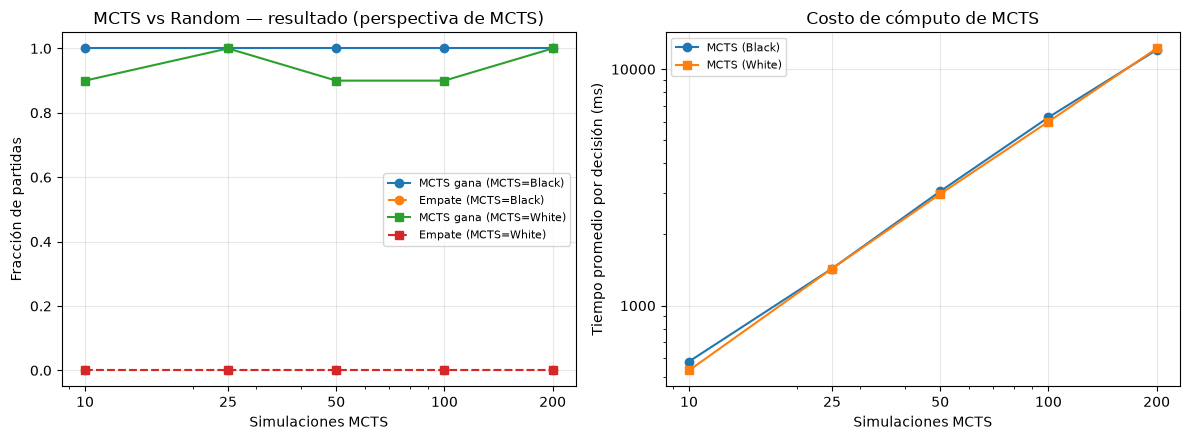

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for pos, marker in [('Black', 'o'), ('White', 's')]:
    sub = df_exp1[df_exp1.mcts_position == pos]
    axes[0].plot(sub.simulations, sub.mcts_win_rate, marker=marker, label=f'MCTS gana (MCTS={pos})')
    axes[0].plot(sub.simulations, sub.draw_rate, marker=marker, linestyle='--', label=f'Empate (MCTS={pos})')
axes[0].set_xlabel('Simulaciones MCTS')
axes[0].set_ylabel('Fracción de partidas')
axes[0].set_title('MCTS vs Random — resultado (perspectiva de MCTS)')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], sim_grid)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for pos, marker in [('Black', 'o'), ('White', 's')]:
    sub = df_exp1[df_exp1.mcts_position == pos]
    axes[1].plot(sub.simulations, sub.avg_time * 1000, marker=marker, label=f'MCTS ({pos})')
axes[1].set_xlabel('Simulaciones MCTS')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo de cómputo de MCTS')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], sim_grid)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp1_mcts_vs_random.png')
plt.show()

### Experimento 2 — MiniMax vs Random: efecto de la profundidad

Se varía `depth` en `[1, 2, 3]`. Con `depth=1`, MiniMax evalúa sólo movidas inmediatas;
dado que `eval()` devuelve 0 para estados no terminales, **depth=1 es equivalente a Random**
a menos que la jugada gane directamente. Con `depth=2` y `depth=3` ya puede evitar perder y buscar ganar a corto plazo.
MiniMax juega como **Black** y como **White** en cada configuración.

In [ ]:
game_exp2 = NoccaNocca(max_steps=150)
depth_grid = [1, 2, 3]
N_EXP2 = 10

t0 = time.perf_counter()
rows = []
for depth in depth_grid:
    for mm_pos, other_pos in [('Black', 'White'), ('White', 'Black')]:
        specs = {
            mm_pos:    ('minimax', dict(depth=depth)),
            other_pos: ('random', {}),
        }
        df = run_match(game_exp2, specs, n_games=N_EXP2)
        r = df[f'reward_{mm_pos}']
        n_wins  = int((r == 1).sum())
        n_draws = int((r == 0).sum())
        n_loss  = int((r == -1).sum())
        rows.append(dict(
            depth=depth,
            mm_position=mm_pos,
            mm_wins=n_wins, draws=n_draws, random_wins=n_loss,
            n_games=N_EXP2,
            mm_win_rate=n_wins / N_EXP2,
            draw_rate=n_draws / N_EXP2,
            random_win_rate=n_loss / N_EXP2,
            avg_reward=r.mean(),
            avg_time=df[f'avg_time_{mm_pos}'].mean(),
            truncated_rate=df['truncated'].mean(),
        ))
experiment_times['Exp2: MiniMax vs Random'] = (time.perf_counter() - t0, len(depth_grid) * 2 * N_EXP2)

df_exp2 = pd.DataFrame(rows)
df_exp2

,depth,mm_position,mm_wins,draws,random_wins,n_games,mm_win_rate,draw_rate,random_win_rate,avg_reward,avg_time,truncated_rate
0,1,Black,5,1,4,10,0.5,0.1,0.4,0.1,0.002366,0.1
1,1,White,5,2,3,10,0.5,0.2,0.3,0.2,0.002219,0.3
2,2,Black,8,0,2,10,0.8,0.0,0.2,0.6,0.062219,0.0
3,2,White,6,0,4,10,0.6,0.0,0.4,0.2,0.061505,0.0
4,3,Black,10,0,0,10,1.0,0.0,0.0,1.0,1.589308,0.0
5,3,White,9,1,0,10,0.9,0.1,0.0,0.9,1.730274,0.3


Figura guardada en ../informe/figures/NoccaNocca/exp2_minimax_vs_random.png


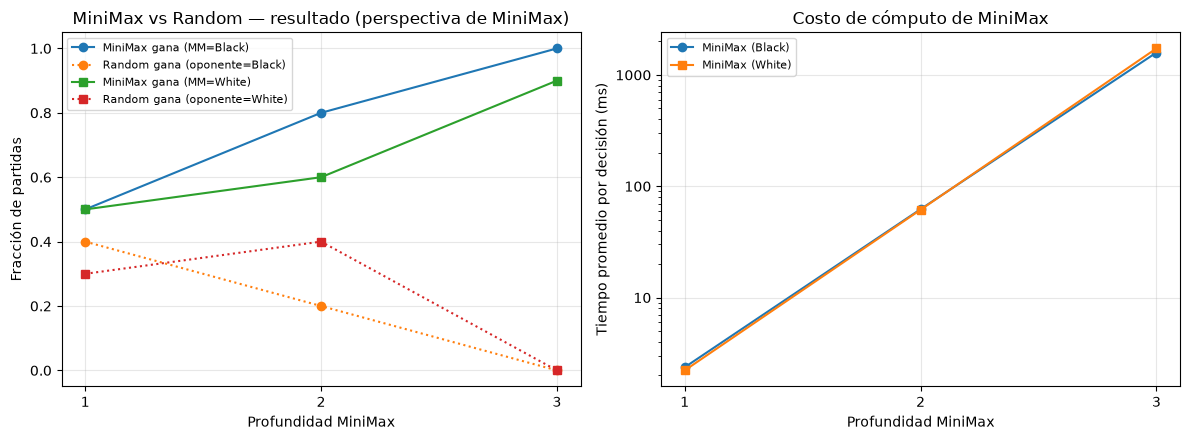

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for pos, marker in [('Black', 'o'), ('White', 's')]:
    sub = df_exp2[df_exp2.mm_position == pos]
    axes[0].plot(sub.depth, sub.mm_win_rate, marker=marker, label=f'MiniMax gana (MM={pos})')
    axes[0].plot(sub.depth, sub.random_win_rate, marker=marker, linestyle=':', label=f'Random gana (oponente={pos})')
axes[0].set_xlabel('Profundidad MiniMax')
axes[0].set_ylabel('Fracción de partidas')
axes[0].set_title('MiniMax vs Random — resultado (perspectiva de MiniMax)')
axes[0].set_xticks(depth_grid)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for pos, marker in [('Black', 'o'), ('White', 's')]:
    sub = df_exp2[df_exp2.mm_position == pos]
    axes[1].plot(sub.depth, sub.avg_time * 1000, marker=marker, label=f'MiniMax ({pos})')
axes[1].set_xlabel('Profundidad MiniMax')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo de cómputo de MiniMax')
axes[1].set_xticks(depth_grid)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp2_minimax_vs_random.png')
plt.show()

### Experimento 3 — MCTS vs MiniMax

Se enfrenta MCTS (variando `simulations` en `[25, 50, 100, 200]`) contra MiniMax (variando `depth` en `[1, 2, 3]`).
Por cada combinación se juegan `N_EXP3` partidas con MCTS como Black y otras `N_EXP3` con MCTS como White; los resultados se fusionan.
Todo se reporta **desde la perspectiva de MCTS**.

In [ ]:
game_exp3 = NoccaNocca(max_steps=150)
sim_grid_3 = [25, 50, 100]
depth_grid_3 = [1, 2, 3]
N_EXP3 = 10

t0 = time.perf_counter()
rows = []
for sims in sim_grid_3:
    for depth in depth_grid_3:
        specs_B = {'Black': ('mcts', dict(simulations=sims, rollouts=5)), 'White': ('minimax', dict(depth=depth))}
        df_B = run_match(game_exp3, specs_B, n_games=N_EXP3)

        specs_W = {'White': ('mcts', dict(simulations=sims, rollouts=5)), 'Black': ('minimax', dict(depth=depth))}
        df_W = run_match(game_exp3, specs_W, n_games=N_EXP3)

        mcts_rewards  = pd.concat([df_B['reward_Black'], df_W['reward_White']], ignore_index=True)
        mcts_times    = pd.concat([df_B['avg_time_Black'], df_W['avg_time_White']], ignore_index=True)
        minimax_times = pd.concat([df_B['avg_time_White'], df_W['avg_time_Black']], ignore_index=True)

        n_total = len(mcts_rewards)
        n_wins  = int((mcts_rewards == 1).sum())
        n_draws = int((mcts_rewards == 0).sum())
        n_loss  = int((mcts_rewards == -1).sum())

        rows.append(dict(
            simulations=sims, minimax_depth=depth,
            mcts_wins=n_wins, draws=n_draws, minimax_wins=n_loss,
            n_games=n_total,
            mcts_win_rate=n_wins / n_total,
            draw_rate=n_draws / n_total,
            minimax_win_rate=n_loss / n_total,
            avg_reward=mcts_rewards.mean(),
            avg_time_mcts=mcts_times.mean(),
            avg_time_minimax=minimax_times.mean(),
        ))
experiment_times['Exp3: MCTS vs MiniMax'] = (time.perf_counter() - t0, len(sim_grid_3) * len(depth_grid_3) * 2 * N_EXP3)

df_exp3 = pd.DataFrame(rows)
df_exp3

,simulations,minimax_depth,mcts_wins,draws,minimax_wins,n_games,mcts_win_rate,draw_rate,minimax_win_rate,avg_reward,avg_time_mcts,avg_time_minimax
0,25,1,17,0,3,20,0.85,0.00,0.15,0.70,1.453278,0.002660
1,25,2,13,0,7,20,0.65,0.00,0.35,0.30,1.219758,0.059440
2,25,3,3,1,16,20,0.15,0.05,0.80,-0.65,1.193518,1.551520
3,50,1,20,0,0,20,1.00,0.00,0.00,1.00,2.968130,0.003045
4,50,2,12,0,8,20,0.60,0.00,0.40,0.20,2.442070,0.058791
5,50,3,10,0,10,20,0.50,0.00,0.50,0.00,2.386054,1.615474
6,100,1,19,0,1,20,0.95,0.00,0.05,0.90,6.212241,0.002381
7,100,2,14,0,6,20,0.70,0.00,0.30,0.40,4.834509,0.056731
8,100,3,10,0,10,20,0.50,0.00,0.50,0.00,5.172777,1.401729
9,200,1,20,0,0,20,1.00,0.00,0.00,1.00,12.534126,0.002788


Figura guardada en ../informe/figures/NoccaNocca/exp3_mcts_vs_minimax.png


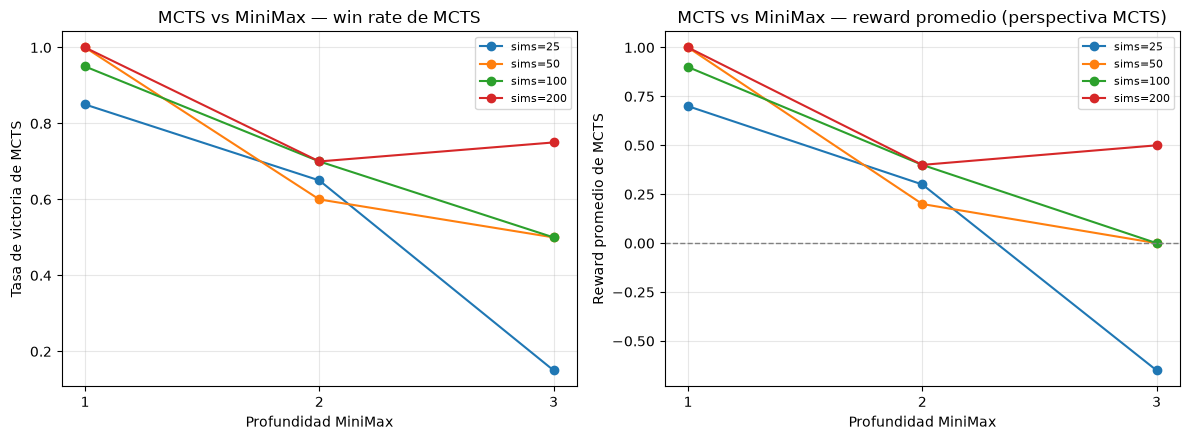

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for sims in sim_grid_3:
    sub = df_exp3[df_exp3.simulations == sims]
    axes[0].plot(sub.minimax_depth, sub.mcts_win_rate, marker='o', label=f'sims={sims}')
axes[0].set_xlabel('Profundidad MiniMax')
axes[0].set_ylabel('Tasa de victoria de MCTS')
axes[0].set_title('MCTS vs MiniMax — win rate de MCTS')
axes[0].set_xticks(depth_grid_3)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for sims in sim_grid_3:
    sub = df_exp3[df_exp3.simulations == sims]
    axes[1].plot(sub.minimax_depth, sub.avg_reward, marker='o', label=f'sims={sims}')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Profundidad MiniMax')
axes[1].set_ylabel('Reward promedio de MCTS')
axes[1].set_title('MCTS vs MiniMax — reward promedio (perspectiva MCTS)')
axes[1].set_xticks(depth_grid_3)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp3_mcts_vs_minimax.png')
plt.show()

### Experimento 4 — MCTS vs MCTS

**4a — Self-play simétrico:** ambos agentes usan el mismo presupuesto de simulaciones.
Cualquier asimetría en los resultados refleja la ventaja de mover primero (Black).
A medida que crece el presupuesto, el `draw_rate` debería aumentar si los agentes convergen al equilibrio.

**4b — Presupuesto asimétrico:** Black varía `simulations`; White fijo en `simulations=50`.
Se mide si más cómputo se traduce en más victorias en un enfrentamiento directo.

In [23]:
game_exp4 = NoccaNocca(max_steps=150)
sim_grid_4 = [25, 50, 100]
N_EXP4A = 10

t0 = time.perf_counter()
rows_4a = []
for sims in sim_grid_4:
    specs = {
        'Black': ('mcts', dict(simulations=sims, rollouts=5)),
        'White': ('mcts', dict(simulations=sims, rollouts=5)),
    }
    df = run_match(game_exp4, specs, n_games=N_EXP4A)
    n_b = int((df.reward_Black == 1).sum())
    n_d = int((df.reward_Black == 0).sum())
    n_w = int((df.reward_Black == -1).sum())
    rows_4a.append(dict(
        simulations=sims,
        wins_Black=n_b, draws=n_d, wins_White=n_w,
        n_games=N_EXP4A,
        win_rate_Black=n_b / N_EXP4A,
        draw_rate=n_d / N_EXP4A,
        win_rate_White=n_w / N_EXP4A,
        avg_time=pd.concat([df.avg_time_Black, df.avg_time_White]).mean(),
    ))
experiment_times['Exp4a: MCTS vs MCTS (self-play simétrico)'] = (time.perf_counter() - t0, len(sim_grid_4) * N_EXP4A)

df_exp4a = pd.DataFrame(rows_4a)
df_exp4a

,simulations,wins_Black,draws,wins_White,n_games,win_rate_Black,draw_rate,win_rate_White,avg_time
0,25,5,0,5,10,0.5,0.0,0.5,1.508384
1,50,2,0,8,10,0.2,0.0,0.8,3.079096
2,100,5,0,5,10,0.5,0.0,0.5,6.611917


In [24]:
OPPONENT_SIMS = 50
N_EXP4B = 10

t0 = time.perf_counter()
rows_4b = []
for sims in sim_grid_4:
    specs = {
        'Black': ('mcts', dict(simulations=sims, rollouts=5)),
        'White': ('mcts', dict(simulations=OPPONENT_SIMS, rollouts=5)),
    }
    df = run_match(game_exp4, specs, n_games=N_EXP4B)
    r = df.reward_Black
    n_b = int((r == 1).sum())
    n_d = int((r == 0).sum())
    n_w = int((r == -1).sum())
    rows_4b.append(dict(
        simulations_black=sims,
        wins_black=n_b, draws=n_d, wins_white=n_w,
        n_games=N_EXP4B,
        win_rate_black=n_b / N_EXP4B,
        draw_rate=n_d / N_EXP4B,
        win_rate_white=n_w / N_EXP4B,
        avg_reward=r.mean(),
    ))
experiment_times['Exp4b: MCTS vs MCTS (presupuesto asimétrico)'] = (time.perf_counter() - t0, len(sim_grid_4) * N_EXP4B)

df_exp4b = pd.DataFrame(rows_4b)
df_exp4b

,simulations_black,wins_black,draws,wins_white,n_games,win_rate_black,draw_rate,win_rate_white,avg_reward
0,25,5,0,5,10,0.5,0.0,0.5,0.0
1,50,3,0,7,10,0.3,0.0,0.7,-0.4
2,100,6,0,4,10,0.6,0.0,0.4,0.2


Figura guardada en ../informe/figures/NoccaNocca/exp4_mcts_vs_mcts.png


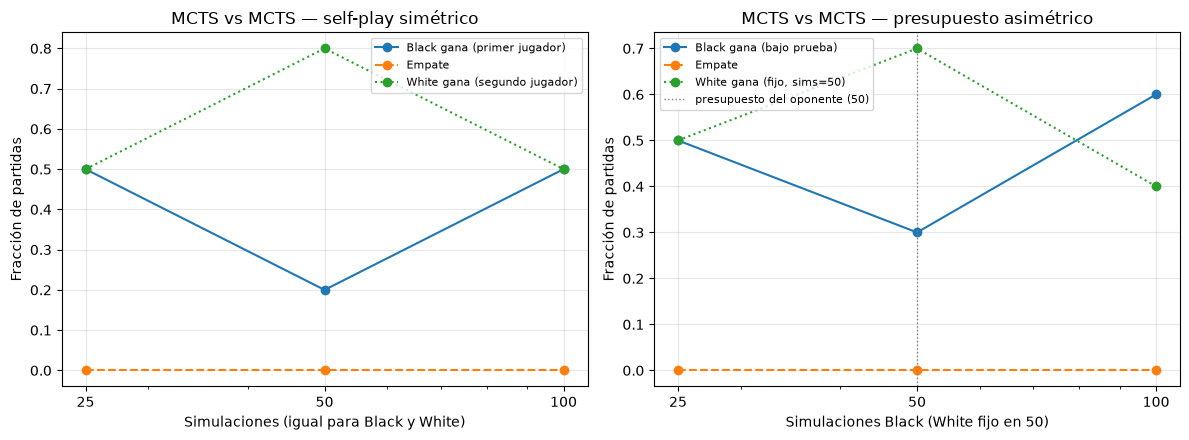

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_exp4a.simulations, df_exp4a.win_rate_Black, marker='o', label='Black gana (primer jugador)')
axes[0].plot(df_exp4a.simulations, df_exp4a.draw_rate, marker='o', linestyle='--', label='Empate')
axes[0].plot(df_exp4a.simulations, df_exp4a.win_rate_White, marker='o', linestyle=':', label='White gana (segundo jugador)')
axes[0].set_xlabel('Simulaciones (igual para Black y White)')
axes[0].set_ylabel('Fracción de partidas')
axes[0].set_title('MCTS vs MCTS — self-play simétrico')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], sim_grid_4)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_exp4b.simulations_black, df_exp4b.win_rate_black, marker='o', label='Black gana (bajo prueba)')
axes[1].plot(df_exp4b.simulations_black, df_exp4b.draw_rate, marker='o', linestyle='--', label='Empate')
axes[1].plot(df_exp4b.simulations_black, df_exp4b.win_rate_white, marker='o', linestyle=':', label=f'White gana (fijo, sims={OPPONENT_SIMS})')
axes[1].axvline(OPPONENT_SIMS, color='gray', linestyle=':', linewidth=1, label=f'presupuesto del oponente ({OPPONENT_SIMS})')
axes[1].set_xlabel(f'Simulaciones Black (White fijo en {OPPONENT_SIMS})')
axes[1].set_ylabel('Fracción de partidas')
axes[1].set_title('MCTS vs MCTS — presupuesto asimétrico')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], sim_grid_4)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp4_mcts_vs_mcts.png')
plt.show()

### Convergencia al Nash Equilibrium — MCTS

El Nash equilibrium de Nocca Nocca **no se conoce analíticamente**. La línea roja marca `reward = 0` (empate simétrico) como referencia. Si el juego tiene ventaja de primer jugador determinística, el Nash real podría estar en ±1; si es un empate forzado, estaría en 0. Las gráficas muestran el reward promedio de cada agente para detectar si hay convergencia o no.

Figura guardada en ../informe/figures/NoccaNocca/nash_mcts_selfplay_convergence.png


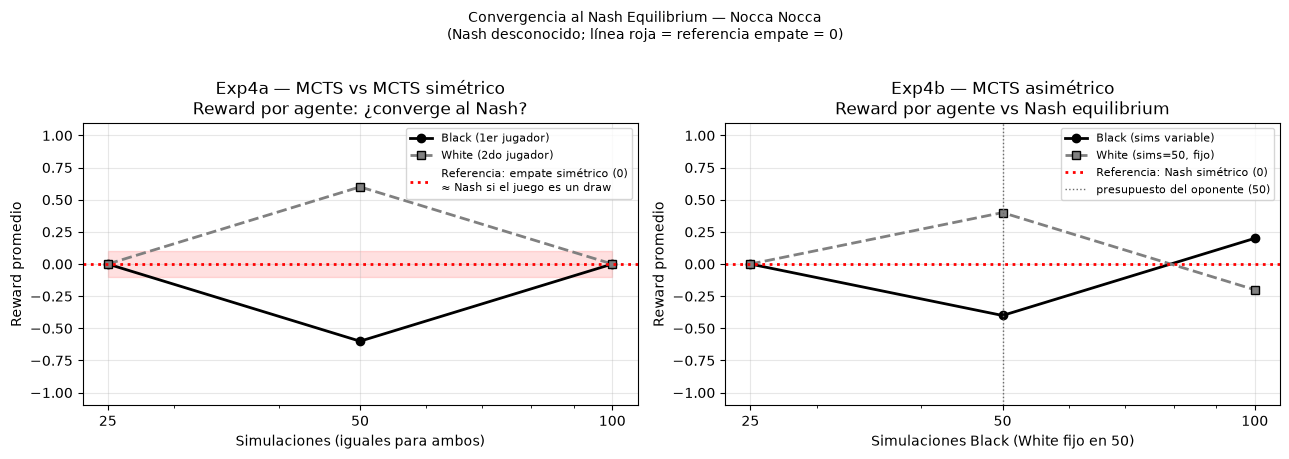

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Exp4a: reward por agente vs simulaciones (self-play simétrico) ──────────
avg_r_Black_4a = df_exp4a.win_rate_Black - df_exp4a.win_rate_White
avg_r_White_4a = -avg_r_Black_4a

axes[0].plot(df_exp4a.simulations, avg_r_Black_4a, marker='o', color='black',
             linewidth=2, label='Black (1er jugador)')
axes[0].plot(df_exp4a.simulations, avg_r_White_4a, marker='s', linestyle='--',
             color='gray', markeredgecolor='black', linewidth=2, label='White (2do jugador)')
axes[0].axhline(0, color='red', linestyle=':', linewidth=2,
                label='Referencia: empate simétrico (0)\n≈ Nash si el juego es un draw')
axes[0].fill_between(df_exp4a.simulations, -0.1, 0.1, alpha=0.12, color='red')
axes[0].set_xlabel('Simulaciones (iguales para ambos)')
axes[0].set_ylabel('Reward promedio')
axes[0].set_title('Exp4a — MCTS vs MCTS simétrico\nReward por agente: ¿converge al Nash?')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], sim_grid_4)
axes[0].set_ylim(-1.1, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Exp4b: reward con presupuesto asimétrico ────────────────────────────────
avg_r_White_4b = -df_exp4b.avg_reward

axes[1].plot(df_exp4b.simulations_black, df_exp4b.avg_reward, marker='o', color='black',
             linewidth=2, label='Black (sims variable)')
axes[1].plot(df_exp4b.simulations_black, avg_r_White_4b, marker='s', linestyle='--',
             color='gray', markeredgecolor='black', linewidth=2, label=f'White (sims={OPPONENT_SIMS}, fijo)')
axes[1].axhline(0, color='red', linestyle=':', linewidth=2,
                label='Referencia: Nash simétrico (0)')
axes[1].axvline(OPPONENT_SIMS, color='dimgray', linestyle=':', linewidth=1,
                label=f'presupuesto del oponente ({OPPONENT_SIMS})')
axes[1].set_xlabel(f'Simulaciones Black (White fijo en {OPPONENT_SIMS})')
axes[1].set_ylabel('Reward promedio')
axes[1].set_title('Exp4b — MCTS asimétrico\nReward por agente vs Nash equilibrium')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], sim_grid_4)
axes[1].set_ylim(-1.1, 1.1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.suptitle('Convergencia al Nash Equilibrium — Nocca Nocca\n'
             '(Nash desconocido; línea roja = referencia empate = 0)',
             fontsize=10, y=1.01)
fig.tight_layout()
savefig(fig, 'nash_mcts_selfplay_convergence.png')
plt.show()


### Experimento 5 — MiniMax vs MiniMax

Ambos jugadores usan MiniMax con distintas profundidades.
Se prueban las combinaciones `depth_Black` × `depth_White` ∈ `{1,2,3}²`.
Todo desde la perspectiva de **Black** (primer jugador en las partidas con `initial_player=0`).

In [ ]:
game_exp5 = NoccaNocca(max_steps=150, initial_player=0)
depth_grid_5 = [1, 2, 3]
N_EXP5 = 10

t0 = time.perf_counter()
rows_5 = []
for d_b in depth_grid_5:
    for d_w in depth_grid_5:
        specs = {
            'Black': ('minimax', dict(depth=d_b)),
            'White': ('minimax', dict(depth=d_w)),
        }
        df = run_match(game_exp5, specs, n_games=N_EXP5)
        r = df.reward_Black
        n_b = int((r == 1).sum())
        n_d = int((r == 0).sum())
        n_w = int((r == -1).sum())
        rows_5.append(dict(
            depth_Black=d_b, depth_White=d_w,
            wins_Black=n_b, draws=n_d, wins_White=n_w,
            n_games=N_EXP5,
            win_rate_Black=n_b / N_EXP5,
            draw_rate=n_d / N_EXP5,
            win_rate_White=n_w / N_EXP5,
            avg_reward_Black=r.mean(),
            avg_time_Black=df.avg_time_Black.mean(),
            avg_time_White=df.avg_time_White.mean(),
        ))
experiment_times['Exp5: MiniMax vs MiniMax'] = (time.perf_counter() - t0, len(depth_grid_5)**2 * N_EXP5)

df_exp5 = pd.DataFrame(rows_5)
df_exp5

,depth_Black,depth_White,wins_Black,draws,wins_White,n_games,win_rate_Black,draw_rate,win_rate_White,avg_reward_Black,avg_time_Black,avg_time_White
0,1,1,4,0,6,10,0.4,0.0,0.6,-0.2,0.002559,0.002509
1,1,2,5,0,5,10,0.5,0.0,0.5,0.0,0.002418,0.064242
2,1,3,2,0,8,10,0.2,0.0,0.8,-0.6,0.002454,1.810296
3,2,1,4,3,3,10,0.4,0.3,0.3,0.1,0.069177,0.002374
4,2,2,4,3,3,10,0.4,0.3,0.3,0.1,0.058184,0.057198
5,2,3,1,0,9,10,0.1,0.0,0.9,-0.8,0.066521,1.839036
6,3,1,9,1,0,10,0.9,0.1,0.0,0.9,1.726037,0.002068
7,3,2,10,0,0,10,1.0,0.0,0.0,1.0,1.623652,0.060455
8,3,3,5,0,5,10,0.5,0.0,0.5,0.0,1.757626,1.646401


Figura guardada en ../informe/figures/NoccaNocca/exp5_minimax_vs_minimax.png


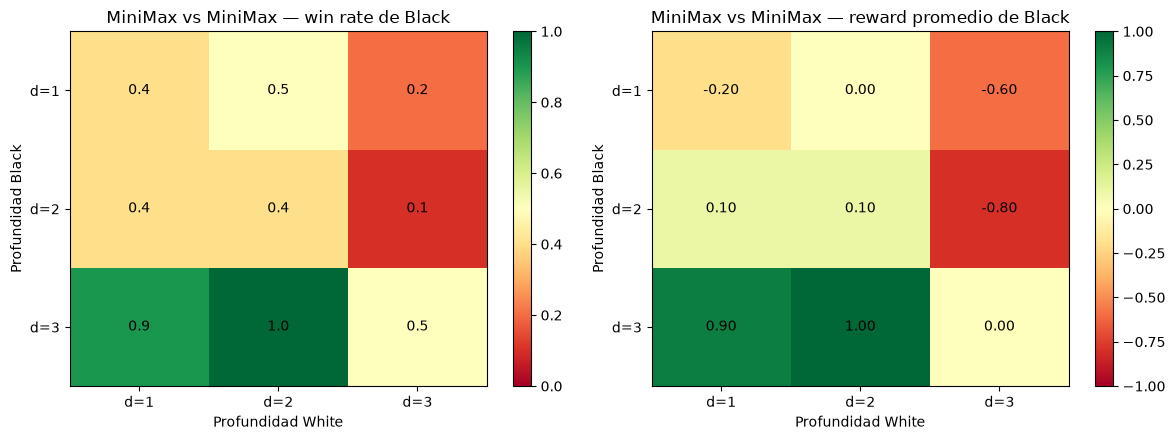

In [28]:
pivot_wr = df_exp5.pivot(index='depth_Black', columns='depth_White', values='win_rate_Black')
pivot_reward = df_exp5.pivot(index='depth_Black', columns='depth_White', values='avg_reward_Black')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].imshow(pivot_wr.values, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(len(depth_grid_5)))
axes[0].set_xticklabels([f'd={d}' for d in depth_grid_5])
axes[0].set_yticks(range(len(depth_grid_5)))
axes[0].set_yticklabels([f'd={d}' for d in depth_grid_5])
axes[0].set_xlabel('Profundidad White')
axes[0].set_ylabel('Profundidad Black')
axes[0].set_title('MiniMax vs MiniMax — win rate de Black')
for i in range(len(depth_grid_5)):
    for j in range(len(depth_grid_5)):
        axes[0].text(j, i, f'{pivot_wr.values[i,j]:.1f}', ha='center', va='center', fontsize=10)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pivot_reward.values, vmin=-1, vmax=1, cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(len(depth_grid_5)))
axes[1].set_xticklabels([f'd={d}' for d in depth_grid_5])
axes[1].set_yticks(range(len(depth_grid_5)))
axes[1].set_yticklabels([f'd={d}' for d in depth_grid_5])
axes[1].set_xlabel('Profundidad White')
axes[1].set_ylabel('Profundidad Black')
axes[1].set_title('MiniMax vs MiniMax — reward promedio de Black')
for i in range(len(depth_grid_5)):
    for j in range(len(depth_grid_5)):
        axes[1].text(j, i, f'{pivot_reward.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
fig.colorbar(im1, ax=axes[1])

fig.tight_layout()
savefig(fig, 'exp5_minimax_vs_minimax.png')
plt.show()

Figura guardada en ../informe/figures/NoccaNocca/nash_minimax_diagonal_convergence.png


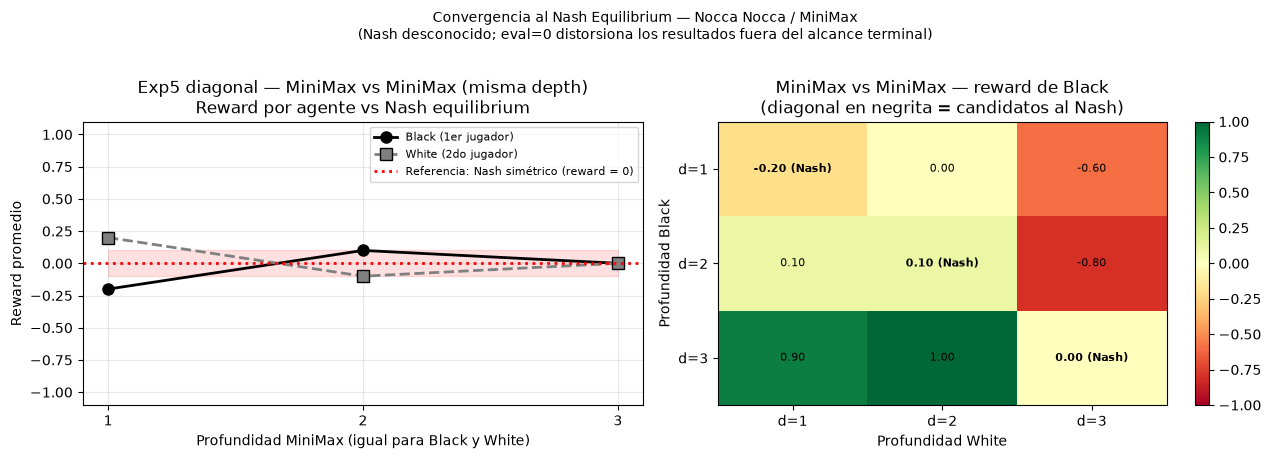

In [29]:

# ── Nash equilibrium — MiniMax vs MiniMax (diagonal: misma profundidad) ─────
# Cuando depth_Black == depth_White, ningún jugador tiene ventaja de cómputo.
# El reward debería fluctuar en torno al valor Nash del juego.
# NOTA: eval()=0 en estados no terminales hace que MiniMax sea equivalente
# a Random fuera de su ventana de búsqueda → los resultados son ruidosos.

diag = df_exp5[df_exp5.depth_Black == df_exp5.depth_White].copy()
diag['avg_reward_White'] = -diag.avg_reward_Black

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: reward en la diagonal vs profundidad
axes[0].plot(diag.depth_Black, diag.avg_reward_Black, marker='o', color='black',
             linewidth=2, markersize=8, label='Black (1er jugador)')
axes[0].plot(diag.depth_Black, diag.avg_reward_White, marker='s', linestyle='--',
             color='gray', markeredgecolor='black', linewidth=2, markersize=8,
             label='White (2do jugador)')
axes[0].axhline(0, color='red', linestyle=':', linewidth=2,
                label='Referencia: Nash simétrico (reward = 0)')
axes[0].fill_between(diag.depth_Black, -0.1, 0.1, alpha=0.12, color='red')
axes[0].set_xlabel('Profundidad MiniMax (igual para Black y White)')
axes[0].set_ylabel('Reward promedio')
axes[0].set_title('Exp5 diagonal — MiniMax vs MiniMax (misma depth)\n'
                  'Reward por agente vs Nash equilibrium')
axes[0].set_xticks(depth_grid_5)
axes[0].set_ylim(-1.1, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Derecha: mapa completo con diagonal resaltada
pivot_reward = df_exp5.pivot(index='depth_Black', columns='depth_White', values='avg_reward_Black')
im = axes[1].imshow(pivot_reward.values, vmin=-1, vmax=1, cmap='RdYlGn', aspect='auto')
for i in range(len(depth_grid_5)):
    for j in range(len(depth_grid_5)):
        val = pivot_reward.values[i, j]
        weight = 'bold' if i == j else 'normal'
        suffix = ' (Nash)' if i == j else ''
        axes[1].text(j, i, f'{val:.2f}{suffix}', ha='center', va='center',
                     fontsize=8, fontweight=weight)
axes[1].set_xticks(range(len(depth_grid_5)))
axes[1].set_xticklabels([f'd={d}' for d in depth_grid_5])
axes[1].set_yticks(range(len(depth_grid_5)))
axes[1].set_yticklabels([f'd={d}' for d in depth_grid_5])
axes[1].set_xlabel('Profundidad White')
axes[1].set_ylabel('Profundidad Black')
axes[1].set_title('MiniMax vs MiniMax — reward de Black\n'
                  '(diagonal en negrita = candidatos al Nash)')
fig.colorbar(im, ax=axes[1])

fig.suptitle('Convergencia al Nash Equilibrium — Nocca Nocca / MiniMax\n'
             '(Nash desconocido; eval=0 distorsiona los resultados fuera del alcance terminal)',
             fontsize=10, y=1.01)
fig.tight_layout()
savefig(fig, 'nash_minimax_diagonal_convergence.png')
plt.show()


### Resumen de tiempos de ejecución

In [30]:
df_times = pd.DataFrame([
    {'experimento': name, 'tiempo_total_s': t, 'partidas_jugadas': n, 'tiempo_por_partida_s': t / n}
    for name, (t, n) in experiment_times.items()
])
total = pd.DataFrame([{
    'experimento': 'TOTAL',
    'tiempo_total_s': df_times.tiempo_total_s.sum(),
    'partidas_jugadas': df_times.partidas_jugadas.sum(),
    'tiempo_por_partida_s': df_times.tiempo_total_s.sum() / df_times.partidas_jugadas.sum(),
}])
pd.concat([df_times, total], ignore_index=True)

,experimento,tiempo_total_s,partidas_jugadas,tiempo_por_partida_s
0,Exp1: MCTS vs Random,1357.735201,40,33.943380
1,Exp4a: MCTS vs MCTS (self-play simétrico),3099.500134,30,103.316671
2,Exp4b: MCTS vs MCTS (presupuesto asimétrico),3551.247272,30,118.374909
3,Exp5: MiniMax vs MiniMax,3794.087180,90,42.156524
4,TOTAL,11802.569787,190,62.118788


## Experimentos Unificados: agente 0 vs agente 1 (juego simétrico)

Siguiendo la misma estructura que `TicTacToe-MCTS.ipynb`, cada experimento enfrenta a **agente 0** y **agente 1** de forma simétrica: agente 0 juega `N` partidas como **Black** (primer jugador) y otras `N` como **White** (segundo jugador); los resultados se combinan desde la perspectiva de agente 0 para cancelar el efecto de la posición.

El Nash equilibrium de Nocca Nocca **no se conoce analíticamente** (a diferencia de Tic-Tac-Toe donde es 0). La función heurística `eval()` devuelve 0 para todos los estados no terminales, lo que limita fuertemente a MiniMax. En consecuencia, **no se incluye una línea Nash fija** en las gráficas; en su lugar, se muestran las curvas de reward de ambos agentes para detectar tendencias de convergencia.

Los cuatro bloques son:
1. **MiniMax vs MiniMax** (depth 1–3): costo computacional y dominancia relativa.
2. **MCTS vs MCTS — simulaciones**: efecto del presupuesto con rollouts=5.
3. **MCTS vs MCTS — rollouts**: efecto de los rollouts con simulations=100.
4. **MCTS vs MiniMax**: reward de MCTS frente a distintas profundidades de MiniMax.

In [7]:
experiment_times_new = {}

def run_symmetric_nn(game, agente0_spec, agente1_spec, n_games_per_side):
    """
    Corre n_games_per_side con agente 0 como Black y n_games_per_side con agente 0 como White.
    Devuelve (rewards_a0, times_a0, times_a1) como pandas Series combinadas.
    """
    df_r1 = run_match(game, {'Black': agente0_spec, 'White': agente1_spec}, n_games=n_games_per_side)
    df_r2 = run_match(game, {'White': agente0_spec, 'Black': agente1_spec}, n_games=n_games_per_side)
    rewards_a0 = pd.concat([df_r1['reward_Black'], df_r2['reward_White']], ignore_index=True)
    times_a0   = pd.concat([df_r1['avg_time_Black'], df_r2['avg_time_White']], ignore_index=True)
    times_a1   = pd.concat([df_r1['avg_time_White'], df_r2['avg_time_Black']], ignore_index=True)
    return rewards_a0, times_a0, times_a1

### Experimento 6 — MiniMax vs MiniMax: efecto de la profundidad

Se enfrenta MiniMax(depth=d) **simétrico** variando `d` de 1 a 3. **Agente 0 juega `N_GAMES_MM_NN_SIDE` partidas como Black y `N_GAMES_MM_NN_SIDE` como White**.

- La función `eval()` es **constante (0)** en estados no terminales, por lo que MiniMax con `depth=1` es prácticamente equivalente a Random.
- A `depth=2` y `depth=3` el agente puede detectar victorias/derrotas dentro de su ventana de búsqueda y actuar en consecuencia.
- `depth>3` es impracticable: con un factor de ramificación ~25 y partidas de hasta 150 turnos, el árbol crece exponencialmente y no hay poda alfa-beta implementada.
- MiniMax es **determinístico** dado un estado, por lo que `N=5` partidas por lado son suficientes para distinguir configuraciones.

In [ ]:
game_exp6 = NoccaNocca(max_steps=200, initial_player=0)
depth_grid_mm_nn = [1, 2, 3, 4]
N_GAMES_MM_NN_SIDE = 5  # por lado → 6 partidas por profundidad

t0 = time.perf_counter()
rows = []
n_depths = len(depth_grid_mm_nn)
for i, depth in enumerate(depth_grid_mm_nn, 1):
    print(f'[{i}/{n_depths}] depth={depth} ...')
    t_depth = time.perf_counter()
    agente0_spec = ('minimax', dict(depth=depth))
    agente1_spec = ('minimax', dict(depth=depth))
    rewards_a0, times_a0, times_a1 = run_symmetric_nn(game_exp6, agente0_spec, agente1_spec, N_GAMES_MM_NN_SIDE)
    elapsed = time.perf_counter() - t_depth
    n_total = 2 * N_GAMES_MM_NN_SIDE
    wins0 = int((rewards_a0 == 1).sum())
    draws = int((rewards_a0 == 0).sum())
    wins1 = int((rewards_a0 == -1).sum())
    print(f'  -> W0={wins0} D={draws} W1={wins1}  avg_t0={times_a0.mean()*1000:.1f}ms  avg_t1={times_a1.mean()*1000:.1f}ms  [{elapsed:.1f}s]')
    rows.append(dict(
        depth=depth,
        wins_agente0=wins0,
        draws=draws,
        wins_agente1=wins1,
        n_games=n_total,
        win_rate_agente0=float((rewards_a0 == 1).mean()),
        draw_rate=float((rewards_a0 == 0).mean()),
        win_rate_agente1=float((rewards_a0 == -1).mean()),
        avg_reward_agente0=float(rewards_a0.mean()),
        avg_time_agente0_ms=float(times_a0.mean()) * 1000,
        avg_time_agente1_ms=float(times_a1.mean()) * 1000,
    ))
print(f'Exp6 completado en {time.perf_counter()-t0:.1f}s')
experiment_times_new['Exp6: MiniMax vs MiniMax (depth 1–3)'] = (
    time.perf_counter() - t0, len(depth_grid_mm_nn) * 2 * N_GAMES_MM_NN_SIDE)

df_exp6 = pd.DataFrame(rows)
df_exp6

[1/4] depth=1 ...
  -> W0=4 D=0 W1=6  avg_t0=0.6ms  avg_t1=0.6ms  [0.5s]
[2/4] depth=2 ...
  -> W0=5 D=2 W1=3  avg_t0=13.1ms  avg_t1=13.2ms  [16.0s]
[3/4] depth=3 ...
  -> W0=6 D=0 W1=4  avg_t0=384.8ms  avg_t1=386.1ms  [292.8s]
[4/4] depth=4 ...


Figura guardada en ../informe/figures/NoccaNocca/exp6_minimax_vs_minimax.png


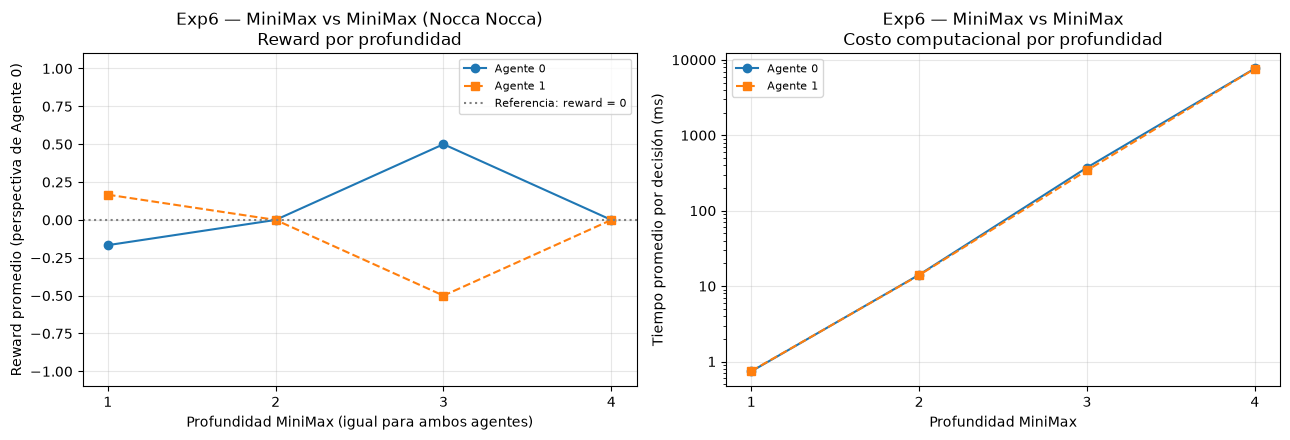

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

avg_r_a0 = df_exp6.avg_reward_agente0
avg_r_a1 = -avg_r_a0

axes[0].plot(df_exp6.depth, avg_r_a0, marker='o', label='Agente 0')
axes[0].plot(df_exp6.depth, avg_r_a1, marker='s', linestyle='--', label='Agente 1')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=1.5, label='Referencia: reward = 0')
axes[0].set_xlabel('Profundidad MiniMax (igual para ambos agentes)')
axes[0].set_ylabel('Reward promedio (perspectiva de Agente 0)')
axes[0].set_title('Exp6 — MiniMax vs MiniMax (Nocca Nocca)\nReward por profundidad')
axes[0].set_xticks(depth_grid_mm_nn)
axes[0].set_ylim(-1.1, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# axes[1].plot(df_exp6.depth, df_exp6.avg_time_agente0_ms, marker='o', label='Agente 0')
# axes[1].plot(df_exp6.depth, df_exp6.avg_time_agente1_ms, marker='s', linestyle='--', label='Agente 1')
# axes[1].set_xlabel('Profundidad MiniMax')
# axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
# axes[1].set_title('Exp6 — MiniMax vs MiniMax\nCosto computacional por profundidad')

axes[1].plot(df_exp6.depth, df_exp6.avg_time_agente0_ms / 1000, marker='o', label='Agente 0')
axes[1].plot(df_exp6.depth, df_exp6.avg_time_agente1_ms / 1000, marker='s', linestyle='--', label='Agente 1')
axes[1].set_xlabel('Profundidad MiniMax')
axes[1].set_ylabel('Tiempo promedio por decisión (s)')
axes[1].set_title('Exp6 — MiniMax vs MiniMax\nCosto computacional por profundidad')



axes[1].set_xticks(depth_grid_mm_nn)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)



fig.tight_layout()
savefig(fig, 'exp6_minimax_vs_minimax.png')
plt.show()

### Experimento 7 — MCTS vs MCTS: efecto del número de simulaciones

Se enfrenta MCTS **simétrico** (ambos agentes usan el mismo presupuesto) variando `simulations` en `[25, 50, 100, 200, 500]`, con `rollouts=5` fijo. **Agente 0 juega N partidas como Black y N como White**.

Se fija `rollouts=5` (en lugar de 10 como en TicTacToe) porque las partidas de Nocca Nocca son mucho más largas (hasta 150 turnos), y rollouts altos escalan el costo proporcionalmente.

A medida que el presupuesto crece, si ambos agentes convergen al juego óptimo, el reward promedio de agente 0 debería estabilizarse (no necesariamente en 0, dado que Nash es desconocido).

In [35]:
game_exp7 = NoccaNocca(max_steps=150, initial_player=0)
sim_grid_mcts_nn = [25, 50, 100, 200, 500]
N_GAMES_MCTS_SIM_NN_SIDE = 10  # por lado → 20 partidas por punto
ROLLOUTS_EXP7 = 5

t0 = time.perf_counter()
rows = []
for sims in sim_grid_mcts_nn:
    agente0_spec = ('mcts', dict(simulations=sims, rollouts=ROLLOUTS_EXP7))
    agente1_spec = ('mcts', dict(simulations=sims, rollouts=ROLLOUTS_EXP7))
    rewards_a0, times_a0, times_a1 = run_symmetric_nn(game_exp7, agente0_spec, agente1_spec, N_GAMES_MCTS_SIM_NN_SIDE)
    n_total = 2 * N_GAMES_MCTS_SIM_NN_SIDE
    rows.append(dict(
        simulations=sims,
        wins_agente0=int((rewards_a0 == 1).sum()),
        draws=int((rewards_a0 == 0).sum()),
        wins_agente1=int((rewards_a0 == -1).sum()),
        n_games=n_total,
        win_rate_agente0=float((rewards_a0 == 1).mean()),
        draw_rate=float((rewards_a0 == 0).mean()),
        win_rate_agente1=float((rewards_a0 == -1).mean()),
        avg_reward_agente0=float(rewards_a0.mean()),
        avg_time_agente0_ms=float(times_a0.mean()) * 1000,
        avg_time_agente1_ms=float(times_a1.mean()) * 1000,
    ))
experiment_times_new['Exp7: MCTS vs MCTS (simulaciones)'] = (
    time.perf_counter() - t0, len(sim_grid_mcts_nn) * 2 * N_GAMES_MCTS_SIM_NN_SIDE)

df_exp7 = pd.DataFrame(rows)
df_exp7

,simulations,wins_agente0,draws,wins_agente1,n_games,win_rate_agente0,draw_rate,win_rate_agente1,avg_reward_agente0,avg_time_agente0_ms,avg_time_agente1_ms
0,25,8,0,12,20,0.40,0.0,0.60,-0.2,1451.098310,1453.907202
1,50,12,0,8,20,0.60,0.0,0.40,0.2,3088.794789,3089.940767
2,100,10,0,10,20,0.50,0.0,0.50,0.0,6251.942587,6256.204489
3,200,11,0,9,20,0.55,0.0,0.45,0.1,12295.895918,12380.896126
4,500,10,0,10,20,0.50,0.0,0.50,0.0,30683.244170,30817.629374


Figura guardada en ../informe/figures/NoccaNocca/exp7_mcts_vs_mcts_simulations.png


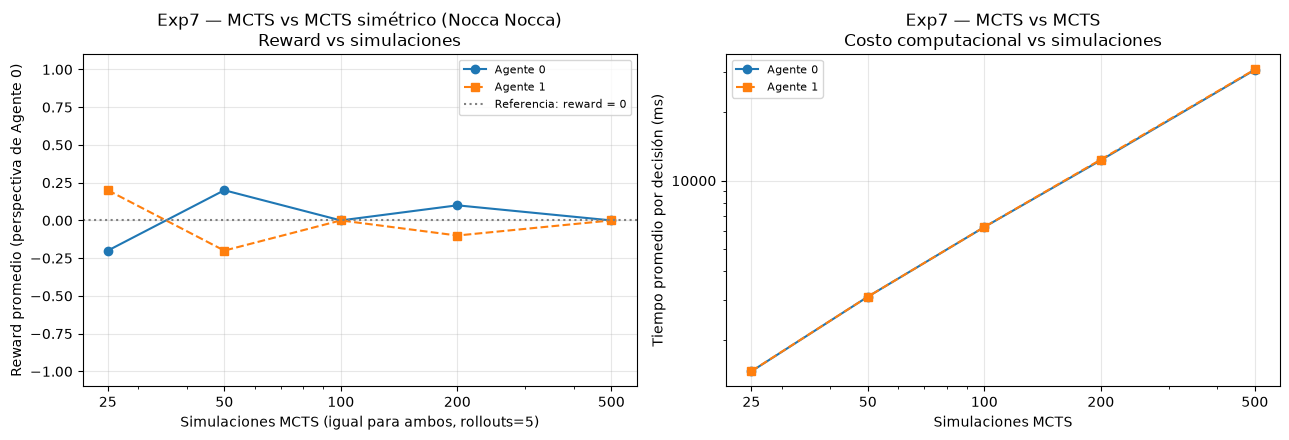

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

avg_r_a0 = df_exp7.avg_reward_agente0
avg_r_a1 = -avg_r_a0

axes[0].plot(df_exp7.simulations, avg_r_a0, marker='o', label='Agente 0')
axes[0].plot(df_exp7.simulations, avg_r_a1, marker='s', linestyle='--', label='Agente 1')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=1.5, label='Referencia: reward = 0')
axes[0].set_xlabel(f'Simulaciones MCTS (igual para ambos, rollouts={ROLLOUTS_EXP7})')
axes[0].set_ylabel('Reward promedio (perspectiva de Agente 0)')
axes[0].set_title('Exp7 — MCTS vs MCTS simétrico (Nocca Nocca)\nReward vs simulaciones')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], sim_grid_mcts_nn)
axes[0].set_ylim(-1.1, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_exp7.simulations, df_exp7.avg_time_agente0_ms, marker='o', label='Agente 0')
axes[1].plot(df_exp7.simulations, df_exp7.avg_time_agente1_ms, marker='s', linestyle='--', label='Agente 1')
axes[1].set_xlabel('Simulaciones MCTS')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Exp7 — MCTS vs MCTS\nCosto computacional vs simulaciones')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], sim_grid_mcts_nn)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp7_mcts_vs_mcts_simulations.png')
plt.show()

### Experimento 8 — MCTS vs MCTS: efecto del número de rollouts

Se enfrenta MCTS **simétrico** variando `rollouts` en `[1, 5, 10, 20]`, con `simulations=100` fijo. **Agente 0 juega N partidas como Black y N como White**.

Más rollouts reducen la varianza de la estimación del valor de cada nodo (promedio de más trayectorias aleatorias hasta el estado terminal), pero aumentan el costo por simulación proporcionalmente a la longitud de las partidas (~40–100 turnos en Nocca Nocca). Se limita a `rollouts=20` para mantener tiempos razonables.

In [37]:
game_exp8 = NoccaNocca(max_steps=150, initial_player=0)
rollout_grid_nn = [1, 5, 10, 20]
N_GAMES_MCTS_ROLL_NN_SIDE = 10  # por lado → 20 partidas por punto
SIMS_EXP8 = 100

t0 = time.perf_counter()
rows = []
for rollouts in rollout_grid_nn:
    agente0_spec = ('mcts', dict(simulations=SIMS_EXP8, rollouts=rollouts))
    agente1_spec = ('mcts', dict(simulations=SIMS_EXP8, rollouts=rollouts))
    rewards_a0, times_a0, times_a1 = run_symmetric_nn(game_exp8, agente0_spec, agente1_spec, N_GAMES_MCTS_ROLL_NN_SIDE)
    n_total = 2 * N_GAMES_MCTS_ROLL_NN_SIDE
    rows.append(dict(
        rollouts=rollouts,
        wins_agente0=int((rewards_a0 == 1).sum()),
        draws=int((rewards_a0 == 0).sum()),
        wins_agente1=int((rewards_a0 == -1).sum()),
        n_games=n_total,
        win_rate_agente0=float((rewards_a0 == 1).mean()),
        draw_rate=float((rewards_a0 == 0).mean()),
        win_rate_agente1=float((rewards_a0 == -1).mean()),
        avg_reward_agente0=float(rewards_a0.mean()),
        avg_time_agente0_ms=float(times_a0.mean()) * 1000,
        avg_time_agente1_ms=float(times_a1.mean()) * 1000,
    ))
experiment_times_new['Exp8: MCTS vs MCTS (rollouts)'] = (
    time.perf_counter() - t0, len(rollout_grid_nn) * 2 * N_GAMES_MCTS_ROLL_NN_SIDE)

df_exp8 = pd.DataFrame(rows)
df_exp8

,rollouts,wins_agente0,draws,wins_agente1,n_games,win_rate_agente0,draw_rate,win_rate_agente1,avg_reward_agente0,avg_time_agente0_ms,avg_time_agente1_ms
0,1,8,0,12,20,0.40,0.0,0.60,-0.2,1133.804408,1134.486388
1,5,15,0,5,20,0.75,0.0,0.25,0.5,6040.337677,6074.864901
2,10,9,0,11,20,0.45,0.0,0.55,-0.1,12816.499378,12843.547968
3,20,12,0,8,20,0.60,0.0,0.40,0.2,25610.205379,25632.696364


Figura guardada en ../informe/figures/NoccaNocca/exp8_mcts_vs_mcts_rollouts.png


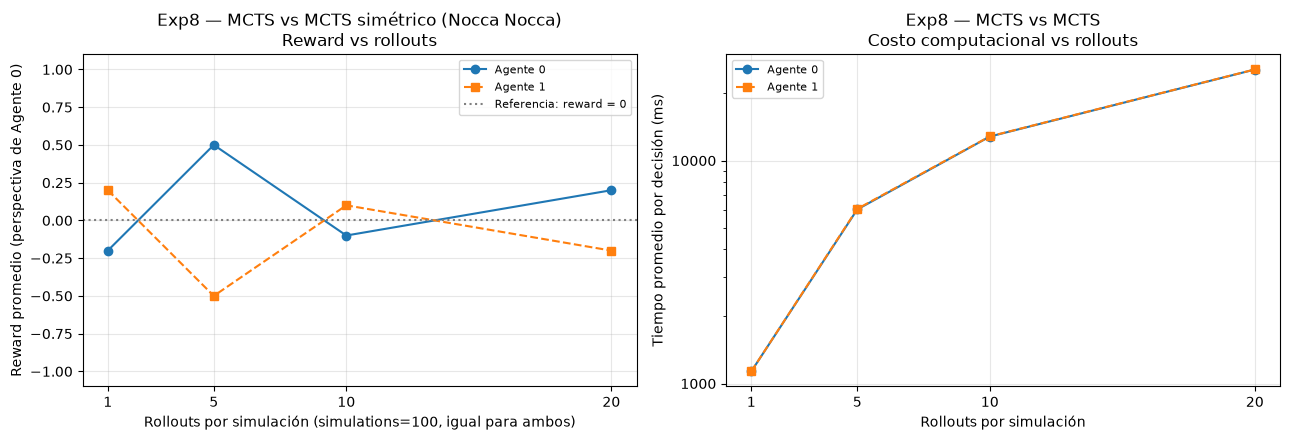

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

avg_r_a0 = df_exp8.avg_reward_agente0
avg_r_a1 = -avg_r_a0

axes[0].plot(df_exp8.rollouts, avg_r_a0, marker='o', label='Agente 0')
axes[0].plot(df_exp8.rollouts, avg_r_a1, marker='s', linestyle='--', label='Agente 1')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=1.5, label='Referencia: reward = 0')
axes[0].set_xlabel(f'Rollouts por simulación (simulations={SIMS_EXP8}, igual para ambos)')
axes[0].set_ylabel('Reward promedio (perspectiva de Agente 0)')
axes[0].set_title('Exp8 — MCTS vs MCTS simétrico (Nocca Nocca)\nReward vs rollouts')
axes[0].set_xticks(rollout_grid_nn)
axes[0].set_ylim(-1.1, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_exp8.rollouts, df_exp8.avg_time_agente0_ms, marker='o', label='Agente 0')
axes[1].plot(df_exp8.rollouts, df_exp8.avg_time_agente1_ms, marker='s', linestyle='--', label='Agente 1')
axes[1].set_xlabel('Rollouts por simulación')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Exp8 — MCTS vs MCTS\nCosto computacional vs rollouts')
axes[1].set_xticks(rollout_grid_nn)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp8_mcts_vs_mcts_rollouts.png')
plt.show()

### Experimento 9 — MCTS vs MiniMax: presupuesto MCTS vs profundidad MiniMax

Se enfrenta MCTS (agente 0, `simulations` variable) contra MiniMax (agente 1, `depth` 1–3). **Agente 0 juega N partidas como Black y N como White**.

**Cómo leer la gráfica:** el reward promedio de agente 0 (MCTS) en función de la profundidad de MiniMax, con una curva por presupuesto de simulaciones. Dado que MiniMax con `eval()=0` es muy débil fuera de su ventana terminal, se espera que MCTS domine ampliamente, especialmente con más simulaciones.

In [23]:
game_exp9 = NoccaNocca(max_steps=120, initial_player=0)
sim_grid_exp9   = [100, 200]
depth_grid_exp9 = [2, 3, 4]
N_GAMES_EXP9_SIDE = 4  # por lado

t0 = time.perf_counter()
rows = []
for sims in sim_grid_exp9:
    for depth in depth_grid_exp9:
        print(f"[Exp2] simulations={sims} depth={depth} ->", end=" ", flush=True)
        agente0_spec = ('mcts', dict(simulations=sims, rollouts=5))
        agente1_spec = ('minimax', dict(depth=depth))
        rewards_a0, times_a0, times_a1 = run_symmetric_nn(
            game_exp9, agente0_spec, agente1_spec, N_GAMES_EXP9_SIDE)
        n_total = 2 * N_GAMES_EXP9_SIDE
        avg_r = float(rewards_a0.mean())
        print(f"avg_reward={avg_r:+.3f}  (W={int((rewards_a0==1).sum())} D={int((rewards_a0==0).sum())} L={int((rewards_a0==-1).sum())})")
        rows.append(dict(
            simulations=sims, minimax_depth=depth,
            wins_agente0=int((rewards_a0 == 1).sum()),
            draws=int((rewards_a0 == 0).sum()),
            wins_agente1=int((rewards_a0 == -1).sum()),
            n_games=n_total,
            win_rate_agente0=float((rewards_a0 == 1).mean()),
            draw_rate=float((rewards_a0 == 0).mean()),
            win_rate_agente1=float((rewards_a0 == -1).mean()),
            avg_reward_agente0=avg_r,
            avg_time_agente0_ms=float(times_a0.mean()) * 1000,
            avg_time_agente1_ms=float(times_a1.mean()) * 1000,
        ))
experiment_times_new['Exp9: MCTS vs MiniMax'] = (
    time.perf_counter() - t0,
    len(sim_grid_exp9) * len(depth_grid_exp9) * 2 * N_GAMES_EXP9_SIDE)

df_exp9 = pd.DataFrame(rows)
df_exp9

[Exp2] simulations=100 depth=2 -> avg_reward=+0.250  (W=5 D=0 L=3)
[Exp2] simulations=100 depth=3 -> avg_reward=+0.750  (W=7 D=0 L=1)
[Exp2] simulations=100 depth=4 -> avg_reward=-0.250  (W=3 D=0 L=5)
[Exp2] simulations=200 depth=2 -> avg_reward=+1.000  (W=8 D=0 L=0)
[Exp2] simulations=200 depth=3 -> avg_reward=+0.750  (W=7 D=0 L=1)
[Exp2] simulations=200 depth=4 -> avg_reward=+0.000  (W=4 D=0 L=4)


,simulations,minimax_depth,wins_agente0,draws,wins_agente1,n_games,win_rate_agente0,draw_rate,win_rate_agente1,avg_reward_agente0,avg_time_agente0_ms,avg_time_agente1_ms
0,100,2,5,0,3,8,0.625,0.0,0.375,0.25,506.253344,11.572346
1,100,3,7,0,1,8,0.875,0.0,0.125,0.75,583.395157,279.404904
2,100,4,3,0,5,8,0.375,0.0,0.625,-0.25,437.521705,5363.113706
3,200,2,8,0,0,8,1.000,0.0,0.000,1.00,920.678519,14.166741
4,200,3,7,0,1,8,0.875,0.0,0.125,0.75,973.859997,260.340787
5,200,4,4,0,4,8,0.500,0.0,0.500,0.00,960.427639,6056.820570


Figura guardada en ../informe/figures/NoccaNocca/exp9_mcts_vs_minimax.png


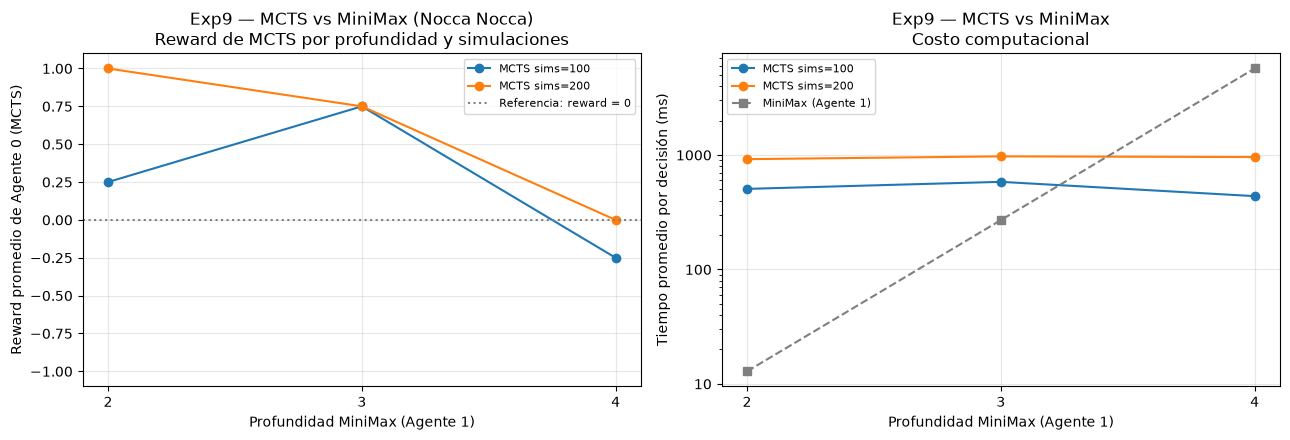

In [25]:
depth_list_exp9 = sorted(df_exp9.minimax_depth.unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for sims in sim_grid_exp9:
    sub = df_exp9[df_exp9.simulations == sims]
    axes[0].plot(sub.minimax_depth, sub.avg_reward_agente0, marker='o', label=f'MCTS sims={sims}')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=1.5, label='Referencia: reward = 0')
axes[0].set_xlabel('Profundidad MiniMax (Agente 1)')
axes[0].set_ylabel('Reward promedio de Agente 0 (MCTS)')
axes[0].set_title('Exp9 — MCTS vs MiniMax (Nocca Nocca)\nReward de MCTS por profundidad y simulaciones')
axes[0].set_xticks(depth_list_exp9)
axes[0].set_ylim(-1.1, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for sims in sim_grid_exp9:
    sub = df_exp9[df_exp9.simulations == sims]
    axes[1].plot(sub.minimax_depth, sub.avg_time_agente0_ms, marker='o', label=f'MCTS sims={sims}')
minimax_time_exp9 = df_exp9.groupby('minimax_depth')['avg_time_agente1_ms'].mean()
axes[1].plot(minimax_time_exp9.index, minimax_time_exp9.values, marker='s', linestyle='--',
             color='tab:gray', label='MiniMax (Agente 1)')
axes[1].set_xlabel('Profundidad MiniMax (Agente 1)')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Exp9 — MCTS vs MiniMax\nCosto computacional')
axes[1].set_xticks(depth_list_exp9)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp9_mcts_vs_minimax.png')
plt.show()

In [18]:
df_times_new = pd.DataFrame([
    {'experimento': k, 'tiempo_total_s': v[0], 'partidas_jugadas': v[1],
     'tiempo_por_partida_s': v[0] / v[1]}
    for k, v in experiment_times_new.items()
])
total_new = pd.DataFrame([{
    'experimento': 'TOTAL (nuevos)',
    'tiempo_total_s': df_times_new.tiempo_total_s.sum(),
    'partidas_jugadas': df_times_new.partidas_jugadas.sum(),
    'tiempo_por_partida_s': df_times_new.tiempo_total_s.sum() / df_times_new.partidas_jugadas.sum(),
}])
pd.concat([df_times_new, total_new], ignore_index=True)

,experimento,tiempo_total_s,partidas_jugadas,tiempo_por_partida_s
0,Exp6: MiniMax vs MiniMax (depth 1–3),4755.666512,24,198.152771
1,Exp9: MCTS vs MiniMax,2753.623527,32,86.050735
2,TOTAL (nuevos),7509.290039,56,134.094465
